# Imports

In [1]:
using CairoMakie
using LinearAlgebra
using CSV, DataFrames, HDF5, LaTeXStrings
using SparseArrays
using Statistics

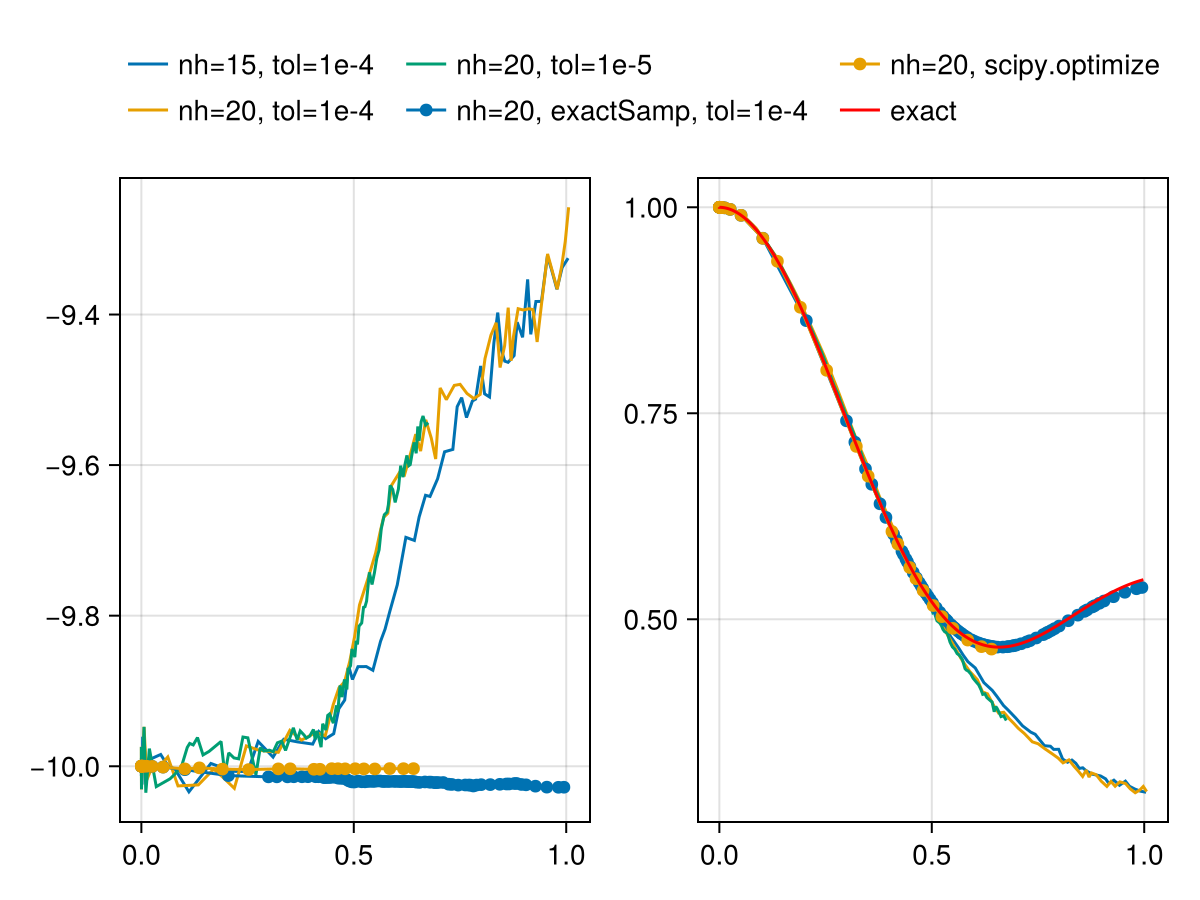

In [67]:
let 
    df = CSV.read("/Users/wladi/Projects/VMC/vmc_jax/scripts/data/data_RBM_ref_L=10_g=-1_num_hidden=15_filter_size=10_numSamples=1000_exactRenorm=False_integratorTol=0.0001_invCutoff=1e-08_tmax=1.0.csv", DataFrame)
    df2 = CSV.read("/Users/wladi/Projects/VMC/vmc_jax/scripts/data/data_RBM_ref_L=10_g=-1_num_hidden=20_filter_size=10_numSamples=1000_exactRenorm=False_integratorTol=0.0001_invCutoff=1e-08_tmax=1.0.csv", DataFrame)

    df3 = CSV.read("/Users/wladi/Projects/VMC/vmc_jax/scripts/data/data_RBM_ref_L=10_g=-1_num_hidden=20_filter_size=10_numSamples=1000_exactRenorm=False_integratorTol=1e-05_invCutoff=1e-08_tmax=1.0.csv", DataFrame)
    df4 = CSV.read("/Users/wladi/Projects/VMC/vmc_jax/scripts/data/data_RBM_ref_exactSamp_L=10_g=-1_num_hidden=20_filter_size=10_numSamples=1000_exactRenorm=False_integratorTol=0.0001_invCutoff=1e-08_tmax=1.0.csv", DataFrame)
    dfCl = CSV.read("/Users/wladi/Projects/VMC/vmc_jax/scripts/data/data_RBM_ref_exactSamp_classOpt_L=10_g=-1_num_hidden=20_filter_size=10_numSamples=1000_exactRenorm=False_integratorTol=0.0001_invCutoff=1e-08_tmax=1.0.csv", DataFrame)

    L, g = 10, -1.
    file_ref = h5open("/Users/wladi/Projects/TCI-VMC/wvfct_ref/psi_L=$(L).h5") 
    t_ref = read(file_ref, "J=-1_g=$(g)/time")
    x_ref = read(file_ref, "J=-1_g=$(g)/xPol")

    f = Figure()
    axE = Axis(f[1,1])
    axX = Axis(f[1,2])

    lines!(axE, df[:,"time"], df[:,"energy"])
    lines!(axE, df2[:,"time"], df2[:,"energy"])
    lines!(axE, df3[:,"time"], df3[:,"energy"])
    scatterlines!(axE, df4[:,"time"], df4[:,"energy"])
    scatterlines!(axE, dfCl[:,"time"], dfCl[:,"energy"])

    lines!(axX, df[:,"time"], df[:,"xPol"], label = "nh=15, tol=1e-4")
    lines!(axX, df2[:,"time"], df2[:,"xPol"], label = "nh=20, tol=1e-4")
    lines!(axX, df3[:,"time"], df3[:,"xPol"], label = "nh=20, tol=1e-5")
    scatterlines!(axX, df4[:,"time"], df4[:,"xPol"], label = "nh=20, exactSamp, tol=1e-4")
    scatterlines!(axX, dfCl[:,"time"], dfCl[:,"xPol"], label = "nh=20, scipy.optimize")
    lines!(axX, t_ref[1:div(end,2)], x_ref[1:div(end,2)], color=:red, label = "exact")

    Legend(f[0,1:2], axX, framecolor=:white, orientation=:horizontal, nbanks=2)

    f
end